# TrOCR / placas españolas (UC3M-LP) en Docker

Adaptado de `TrOCR_IAM.ipynb` (basado en el [cuaderno de Niels Rogge](https://github.com/NielsRogge/Transformers-Tutorials/blob/master/TrOCR/Fine_tune_TrOCR_on_IAM_Handwriting_Database_using_Seq2SeqTrainer.ipynb)).
En lugar de líneas manuscritas de IAM, ajusta TrOCR con los recortes de placas del dataset UC3M-LP
(`data/ocr_vehicles/UC3M-LP`). El modelo resultante (`outputs/trocr_placas/final`) es el OCR que usa
`Pipeline_Placas_OCR.ipynb`.

Selecciona el kernel **Python (TrOCR)**.

Diferencias con el cuaderno de IAM:

* Los recortes de placa se generan a partir de los JSON de UC3M-LP y se guardan con margen extra alrededor de la placa.
* **Aumento de datos** en entrenamiento: en cada época cada placa se recorta con un margen aleatorio (como las cajas
  variables del detector), se rota ligeramente, se cambian brillo, contraste y color, se desenfoca, se comprime en JPEG
  y se reduce a baja resolución. Validación y test usan siempre el mismo recorte que el pipeline.
* UC3M-LP anonimiza dos caracteres de cada placa con un bloque gris. Con `USAR_RELLENAS = True` (por defecto) se
  entrena con el dataset de `Rellenar_UC3M-LP.ipynb`, donde cada bloque se ha sustituido por un carácter real de la
  misma placa, y el modelo se guarda en `outputs/trocr_placas_rellenas`. Con `False` se usan los recortes originales:
  el texto marca los bloques con `*` (`074*C*V`) y el modelo se guarda en `outputs/trocr_placas`.
* Con `USAR_COLOMBIANAS = True` (por defecto) se añaden las placas colombianas de
  `data/ocr_vehicles/new_plates/plates-ocr-train` (recortes nítidos de coches y motos), y el modelo se guarda en
  una carpeta con el sufijo `_colombia` (`outputs/trocr_placas_rellenas_colombia`).
* Las etiquetas no empiezan con `<s>`: el decodificador ya lo recibe como token inicial. Con `<s>` en las etiquetas el
  modelo aprende a predecirlo y, ante placas desconocidas, lo repite hasta el límite y devuelve un texto vacío.
* La validación se separa de `train` agrupando por placa, porque la misma placa aparece en varias fotos. `test` se
  reserva para la evaluación final, que se hace también con las placas reducidas a baja resolución.
* Entrada de 192×384 píxeles (`IMAGE_SIZE`) en lugar de 384×384: una placa es ancha, así que se conserva la resolución
  horizontal con la mitad de parches y el codificador tarda la mitad.
* Batch de 16, hasta 40 épocas con *early stopping* sobre el CER de validación, y se conserva el mejor checkpoint.
* La generación no usa `no_repeat_ngram_size` ni `length_penalty`: en una placa los caracteres pueden repetirse y la
  longitud es fija.

## Preparar los datos

Cada imagen de UC3M-LP tiene un JSON con sus placas: `lp_id` (por ejemplo `AN-074*C*V`; el prefijo antes del guion es
la categoría de la placa y `*` marca los caracteres anonimizados), el polígono de la placa (`poly_coord`) y las cajas de
los caracteres visibles.

Para cada placa se toma el rectángulo que contiene el polígono y se guarda un recorte con `CROP_CONTEXT` de margen, más
amplio que el del pipeline, para que el aumento de datos pueda elegir márgenes distintos. El recorte se reduce a
`CROP_MAX_SIDE` píxeles como máximo (TrOCR lo redimensiona a 384×384 de todos modos). Para cada partición se escribe un
CSV con el texto y la posición de la placa dentro del recorte. Los recortes se generan una sola vez: si ya existen, se
reutilizan.

El campo `imagePath` de los JSON está desplazado una posición (`00000.json` indica `00001.jpg`), así que la imagen se
toma del nombre del propio JSON: `00000.jpg`.

In [4]:
import os
import json
import math
import random
from pathlib import Path

import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

project_dir = Path.cwd()
if project_dir.name == "notebooks":
    project_dir = project_dir.parent
UC3M_DIR = Path(os.environ.get("UC3M_DATA_DIR", project_dir / "data" / "ocr_vehicles" / "UC3M-LP"))
# True: placas con los bloques grises rellenados por Rellenar_UC3M-LP.ipynb. False: placas originales con '*'.
USAR_RELLENAS = True
if USAR_RELLENAS:
    DATA_DIR = Path(os.environ.get("PLATES_OCR_FILLED_DIR",
                                   project_dir / "data" / "ocr_vehicles" / "UC3M-LP_ocr_rellenas"))
    OUTPUT_DIR = Path(os.environ.get("TROCR_OUTPUT_DIR", project_dir / "outputs")) / "trocr_placas_rellenas"
else:
    DATA_DIR = Path(os.environ.get("PLATES_OCR_DATA_DIR", project_dir / "data" / "ocr_vehicles" / "UC3M-LP_ocr"))
    OUTPUT_DIR = Path(os.environ.get("TROCR_OUTPUT_DIR", project_dir / "outputs")) / "trocr_placas"
# True: añade las placas colombianas de new_plates/plates-ocr-train (recortes ya ajustados a la placa).
USAR_COLOMBIANAS = True
COLOMBIA_DIR = Path(os.environ.get("COLOMBIA_PLATES_DIR",
                                   project_dir / "data" / "ocr_vehicles" / "new_plates" / "plates-ocr-train"))
COLOMBIA_REPEAT = 2  # veces que aparece cada placa colombiana por época, con aumentos distintos
if USAR_COLOMBIANAS:
    OUTPUT_DIR = OUTPUT_DIR.with_name(OUTPUT_DIR.name + "_colombia")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CROP_PADDING = (0.08, 0.15)  # (horizontal, vertical), igual que en Pipeline_Placas_OCR.ipynb
CROP_CONTEXT = (0.25, 0.45)  # margen guardado alrededor de la placa, para el aumento de datos
CROP_MAX_SIDE = 768
VALIDATION_FRACTION = 0.1
SEED = 42
# Tamaño (alto, ancho) de entrada al modelo, múltiplo de 16. TrOCR usa (384, 384); una placa es ancha, así que
# (192, 384) conserva la resolución horizontal con la mitad de parches y el codificador tarda la mitad.
IMAGE_SIZE = (128, 128)


def ampliar_caja(caja, padding, ancho, alto):
    x0, y0, x1, y1 = caja
    pad_x = (x1 - x0) * padding[0]
    pad_y = (y1 - y0) * padding[1]
    return (
        max(0, int(x0 - pad_x)),
        max(0, int(y0 - pad_y)),
        min(ancho, math.ceil(x1 + pad_x)),
        min(alto, math.ceil(y1 + pad_y)),
    )


def preparar_recortes(split):
    destino = DATA_DIR / "image" / split
    destino.mkdir(parents=True, exist_ok=True)
    filas = []
    ids = (UC3M_DIR / f"{split}.txt").read_text(encoding="utf-8").split()
    for image_id in tqdm(ids, desc=split):
        anotacion = json.loads((UC3M_DIR / split / f"{image_id}.json").read_text(encoding="utf-8"))
        imagen = None
        for i, placa in enumerate(anotacion["lps"]):
            xs = [x for x, _ in placa["poly_coord"]]
            ys = [y for _, y in placa["poly_coord"]]
            caja = (min(xs), min(ys), max(xs), max(ys))
            contexto = ampliar_caja(caja, CROP_CONTEXT, anotacion["imageWidth"], anotacion["imageHeight"])
            escala = min(1.0, CROP_MAX_SIDE / max(contexto[2] - contexto[0], contexto[3] - contexto[1]))
            nombre = f"{split}/{image_id}_{i}.jpg"
            if not (DATA_DIR / "image" / nombre).is_file():
                if imagen is None:
                    with Image.open(UC3M_DIR / split / f"{image_id}.jpg") as original:
                        imagen = original.convert("RGB")
                    if imagen.size != (anotacion["imageWidth"], anotacion["imageHeight"]):
                        raise ValueError(f"{image_id}: la imagen mide {imagen.size}, el JSON indica otro tamaño")
                recorte = imagen.crop(contexto)
                if escala < 1:
                    recorte = recorte.resize((round(recorte.width * escala), round(recorte.height * escala)),
                                             Image.LANCZOS)
                recorte.save(DATA_DIR / "image" / nombre, quality=95)
            categoria, texto = placa["lp_id"].split("-", 1)
            filas.append({
                "file_name": nombre, "text": texto, "categoria": categoria,
                # posición de la placa dentro del recorte guardado
                "x0": (caja[0] - contexto[0]) * escala, "y0": (caja[1] - contexto[1]) * escala,
                "x1": (caja[2] - contexto[0]) * escala, "y1": (caja[3] - contexto[1]) * escala,
            })
    return pd.DataFrame(filas)


if all((DATA_DIR / f"{split}.csv").is_file() for split in ("train", "validation", "test")):
    print("Recortes ya preparados en", DATA_DIR)
elif USAR_RELLENAS:
    raise FileNotFoundError(f"No existe el dataset rellenado en {DATA_DIR}. Ejecuta antes notebooks/Rellenar_UC3M-LP.ipynb")
else:
    train_all = preparar_recortes("train")
    test_all = preparar_recortes("test")
    # La misma placa aparece en varias fotos: se separa la validación por placa para no evaluar con placas vistas.
    placas = sorted(train_all["text"].unique())
    random.Random(SEED).shuffle(placas)
    placas_validacion = set(placas[:round(len(placas) * VALIDATION_FRACTION)])
    es_validacion = train_all["text"].isin(placas_validacion)
    train_all[~es_validacion].to_csv(DATA_DIR / "train.csv", index=False)
    train_all[es_validacion].to_csv(DATA_DIR / "validation.csv", index=False)
    test_all.to_csv(DATA_DIR / "test.csv", index=False)
    print("Recortes preparados en", DATA_DIR)

Recortes ya preparados en /home/mambauser/workspace/data/ocr_vehicles/UC3M-LP_ocr_rellenas


Leemos las particiones de UC3M-LP y comprobamos que no falta ninguna imagen. Las rutas pasan a ser absolutas y cada
fila indica su `fuente`, porque se mezclan imágenes de carpetas distintas.

Con `USAR_COLOMBIANAS`, se añaden las placas colombianas:

* Las etiquetas se pasan a mayúsculas y se descartan las que no siguen el formato colombiano: `AAA000` en coches y
  `AAA00A` en motos. Así se eliminan unas pocas etiquetas erróneas con un carácter de más, como `OYG6877` para una
  placa `UYG·687`.
* Las imágenes ya son el recorte de la placa, así que su caja es la imagen completa.
* El repositorio original repite 38 placas entre `train` y `valid`. Esas se quedan en entrenamiento y el resto de
  `valid` se reparte por placa entre validación y test, para no evaluar con placas vistas.
* Cada placa colombiana de entrenamiento aparece `COLOMBIA_REPEAT` veces por época (con aumentos distintos), para
  compensar que son menos que las de UC3M-LP.

In [5]:
def read_annotations(path):
    frame = pd.read_csv(path, dtype={"text": str})
    if frame.empty:
        raise ValueError(f"No hay anotaciones en {path}")
    missing = [name for name in frame["file_name"] if not (DATA_DIR / "image" / name).is_file()]
    if missing:
        raise FileNotFoundError(f"Faltan {len(missing)} imagenes; primera: {missing[0]}")
    frame["file_name"] = [str(DATA_DIR / "image" / name) for name in frame["file_name"]]
    frame["fuente"] = "UC3M-LP"
    return frame


def leer_colombianas():
    frames = []
    for split in ("train", "valid"):
        frame = pd.read_csv(COLOMBIA_DIR / f"{split}_annotations.csv", dtype=str)
        frame["text"] = frame["plate_text"].str.strip().str.upper()
        frame["file_name"] = [str(COLOMBIA_DIR / ruta) for ruta in frame["image_path"]]
        frame["split_original"] = split
        frames.append(frame)
    frame = pd.concat(frames, ignore_index=True)
    # coches AAA000 y motos AAA00A
    validas = frame["text"].str.fullmatch(r"[A-Z]{3}[0-9]{2}[0-9A-Z]")
    print("Colombianas descartadas por formato:", frame.loc[~validas, "text"].tolist())
    frame = frame[validas].copy()
    missing = [ruta for ruta in frame["file_name"] if not Path(ruta).is_file()]
    if missing:
        raise FileNotFoundError(f"Faltan {len(missing)} imagenes; primera: {missing[0]}")
    # la imagen ya es el recorte de la placa: su caja es la imagen completa
    tamanos = [Image.open(ruta).size for ruta in frame["file_name"]]
    frame["x0"], frame["y0"] = 0.0, 0.0
    frame["x1"] = [float(w) for w, _ in tamanos]
    frame["y1"] = [float(h) for _, h in tamanos]
    frame["fuente"] = "Colombia"
    return frame[["file_name", "text", "x0", "y0", "x1", "y1", "fuente", "split_original"]]


train_df = read_annotations(DATA_DIR / "train.csv")
eval_df = read_annotations(DATA_DIR / "validation.csv")
test_df = read_annotations(DATA_DIR / "test.csv")

if USAR_COLOMBIANAS:
    colombia = leer_colombianas()
    en_train = set(colombia.loc[colombia["split_original"] == "train", "text"])
    placas_valid = sorted(set(colombia.loc[(colombia["split_original"] == "valid")
                                           & ~colombia["text"].isin(en_train), "text"]))
    random.Random(SEED).shuffle(placas_valid)
    placas_test = set(placas_valid[:len(placas_valid) // 2])
    placas_val = set(placas_valid[len(placas_valid) // 2:])
    colombia_val = colombia[colombia["text"].isin(placas_val)]
    colombia_test = colombia[colombia["text"].isin(placas_test)]
    colombia_train = colombia[~colombia["text"].isin(placas_val | placas_test)]
    train_df = pd.concat([train_df] + [colombia_train] * COLOMBIA_REPEAT, ignore_index=True)
    eval_df = pd.concat([eval_df, colombia_val], ignore_index=True)
    test_df = pd.concat([test_df, colombia_test], ignore_index=True)

for frame in (train_df, eval_df, test_df):
    frame.reset_index(drop=True, inplace=True)
print(f"Entrenamiento: {len(train_df)}; validacion: {len(eval_df)}; test reservado: {len(test_df)}")
print(pd.DataFrame({nombre: frame["fuente"].value_counts() for nombre, frame in
                    (("entrenamiento", train_df), ("validacion", eval_df), ("test", test_df))}))
print("Placas de validacion que tambien estan en entrenamiento:",
      len(set(eval_df["text"]) & set(train_df["text"])))
print("Placas de test que tambien estan en entrenamiento:",
      len(set(test_df["text"]) & set(train_df["text"])))

Colombianas descartadas por formato: ['OYG6877', 'WHV4291', 'CQW5891', 'PEO9599']
Entrenamiento: 3216; validacion: 229; test reservado: 479
          entrenamiento  validacion  test
fuente                                   
UC3M-LP            1620         181   432
Colombia           1596          48    47
Placas de validacion que tambien estan en entrenamiento: 0
Placas de test que tambien estan en entrenamiento: 0


Cada elemento del dataset devuelve:
* `pixel_values`, la entrada del modelo.
* `labels`, los `input_ids` del texto de la placa.

`TrOCRProcessor` agrupa el procesador de imagen (resize a `IMAGE_SIZE` y normalización) y el tokenizador RoBERTa.

Con `augment=True` (solo entrenamiento), cada vez que se lee una placa:

* se rota hasta ±4° el recorte guardado, alrededor de la placa;
* se recorta con un margen aleatorio distinto en cada lado (entre la mitad y el doble del margen del pipeline);
* se cambian brillo, contraste y saturación, y a veces se pasa a escala de grises;
* a veces se desenfoca o se comprime en JPEG con baja calidad;
* la mitad de las veces se reduce a un ancho de 60 a 200 píxeles, el tamaño habitual de las placas que encuentra el
  detector.

En las placas colombianas la caja es la imagen completa, así que el margen aleatorio queda limitado a la imagen y el
giro rellena las esquinas con el color mediano de la placa. Sin aumento se usa el margen fijo del pipeline. `downscale_width` reduce todas las placas a ese ancho, para evaluar a
baja resolución. Las etiquetas terminan en `</s>` pero no empiezan con `<s>`. Los textos de placa ocupan como máximo 9
tokens, así que `max_target_length=16`.

In [7]:
import io

import torch
from torch.utils.data import Dataset
from PIL import ImageEnhance, ImageFilter, ImageOps, ImageStat

class PlateDataset(Dataset):
    def __init__(self, root_dir, df, processor, max_target_length=16, augment=False, downscale_width=None):
        self.root_dir = root_dir
        self.df = df
        self.processor = processor
        self.max_target_length = max_target_length
        self.augment = augment
        self.downscale_width = downscale_width

    def __len__(self):
        return len(self.df)

    def _crop(self, image, row):
        box = (row["x0"], row["y0"], row["x1"], row["y1"])
        if not self.augment:
            return image.crop(ampliar_caja(box, CROP_PADDING, image.width, image.height))
        # random rotation around the plate centre, then a random margin on each side
        center = ((box[0] + box[2]) / 2, (box[1] + box[3]) / 2)
        fill = tuple(int(v) for v in ImageStat.Stat(image).median)
        image = image.rotate(random.uniform(-4, 4), resample=Image.BICUBIC, center=center, fillcolor=fill)
        w, h = box[2] - box[0], box[3] - box[1]
        pad = [random.uniform(0.5, 2.0) * CROP_PADDING[i % 2] for i in range(4)]
        return image.crop((
            max(0, int(box[0] - w * pad[0])), max(0, int(box[1] - h * pad[1])),
            min(image.width, math.ceil(box[2] + w * pad[2])), min(image.height, math.ceil(box[3] + h * pad[3])),
        ))

    def _photometric(self, image):
        image = ImageEnhance.Brightness(image).enhance(random.uniform(0.6, 1.4))
        image = ImageEnhance.Contrast(image).enhance(random.uniform(0.6, 1.4))
        image = ImageEnhance.Color(image).enhance(random.uniform(0.5, 1.5))
        if random.random() < 0.1:
            image = ImageOps.grayscale(image).convert("RGB")
        if random.random() < 0.3:
            image = image.filter(ImageFilter.GaussianBlur(random.uniform(0.3, 1.2)))
        if random.random() < 0.3:
            buffer = io.BytesIO()
            image.save(buffer, format="JPEG", quality=random.randint(30, 90))
            image = Image.open(buffer).convert("RGB")
        return image

    @staticmethod
    def _downscale(image, width):
        height = max(1, round(image.height * width / image.width))
        return image.resize((width, height), Image.BILINEAR)

    def load_image(self, idx):
        row = self.df.iloc[idx]
        image = self._crop(Image.open(self.root_dir + row["file_name"]).convert("RGB"), row)
        if self.augment:
            image = self._photometric(image)
            if random.random() < 0.5:
                # simulate the low-resolution plates produced by the detector
                image = self._downscale(image, random.randint(60, 200))
        elif self.downscale_width:
            image = self._downscale(image, self.downscale_width)
        return image

    def __getitem__(self, idx):
        text = self.df['text'].iloc[idx]
        # prepare image (i.e. resize + normalize)
        pixel_values = self.processor(self.load_image(idx), return_tensors="pt").pixel_values
        # add labels (input_ids) by encoding the text; <s> is already the decoder start token
        tokenizer = self.processor.tokenizer
        labels = tokenizer(text, add_special_tokens=False).input_ids + [tokenizer.eos_token_id]
        labels = labels[:self.max_target_length]
        # important: make sure that PAD tokens are ignored by the loss function
        labels = labels + [-100] * (self.max_target_length - len(labels))

        encoding = {"pixel_values": pixel_values.squeeze(), "labels": torch.tensor(labels)}
        return encoding

Inicializamos los datasets de entrenamiento, validación y test:

In [8]:
from transformers import TrOCRProcessor

processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
processor.image_processor.size = {"height": IMAGE_SIZE[0], "width": IMAGE_SIZE[1]}
train_dataset = PlateDataset(root_dir="",
                             df=train_df,
                             processor=processor,
                             augment=True)
eval_dataset = PlateDataset(root_dir="",
                            df=eval_df,
                            processor=processor)
test_dataset = PlateDataset(root_dir="",
                            df=test_df,
                            processor=processor)
test_low_res_dataset = PlateDataset(root_dir="",
                                    df=test_df,
                                    processor=processor,
                                    downscale_width=100)

/opt/conda/envs/trocr/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [9]:
print("Number of training examples:", len(train_dataset))
print("Number of validation examples:", len(eval_dataset))
print("Number of test examples:", len(test_dataset))

Number of training examples: 3216
Number of validation examples: 229
Number of test examples: 479


Comprobamos un ejemplo del dataset de entrenamiento:

In [6]:
encoding = train_dataset[0]
for k,v in encoding.items():
  print(k, v.shape)

pixel_values torch.Size([3, 128, 128])
labels torch.Size([16])


In [7]:
labels = encoding['labels'].clone()
labels[labels == -100] = processor.tokenizer.pad_token_id
print(processor.tokenizer.convert_ids_to_tokens(encoding['labels'][encoding['labels'] != -100]))
label_str = processor.decode(labels, skip_special_tokens=True)
print(label_str)

['07', '45', 'C', 'K', 'V', '</s>']
0745CKV


Así se ve una misma placa con el recorte de validación y con varias versiones aumentadas:

0745CKV


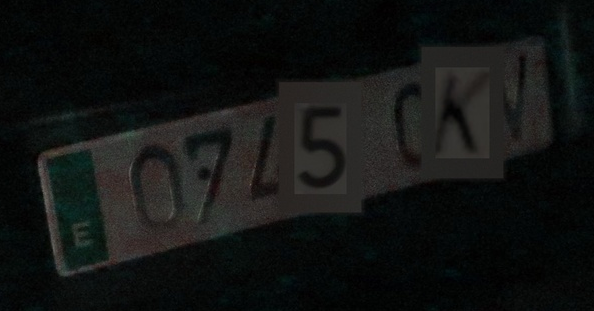

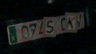

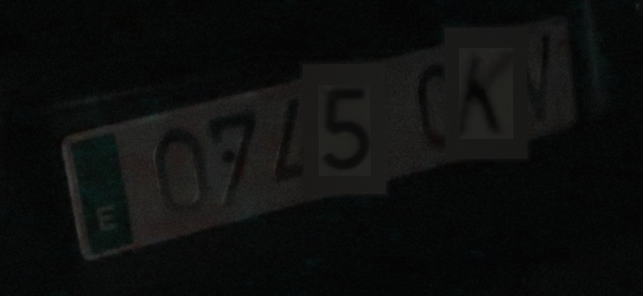

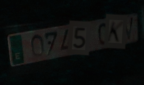

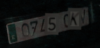

In [8]:
from IPython.display import display

fila = 0
print(train_df["text"][fila])
display(PlateDataset("", train_df, processor).load_image(fila))
for _ in range(4):
    display(train_dataset.load_image(fila))

## Entrenar el modelo

Como en IAM, partimos de `microsoft/trocr-base-stage1`, el checkpoint preentrenado de TrOCR pensado para ajustarlo a un
dominio nuevo.

Su codificador (un ViT) divide la imagen en parches de 16×16 y tiene un *embedding* de posición por parche, preparado
para una rejilla de 24×24 (384×384). Si `IMAGE_SIZE` es otro, esos *embeddings* se interpolan una vez a la nueva
rejilla (12×24 para 192×384) y se guarda el nuevo tamaño en la configuración: el modelo guardado ya espera ese tamaño,
y su procesador redimensiona a él, así que el pipeline no necesita cambios. El ajuste fino adapta el modelo al cambio.

In [9]:
from transformers import VisionEncoderDecoderModel

model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-stage1")


def redimensionar_encoder(model, alto, ancho):
    # interpola los embeddings de posición del ViT a la rejilla (alto/16, ancho/16)
    embeddings = model.encoder.embeddings
    patch = model.config.encoder.patch_size
    posiciones = embeddings.position_embeddings.data
    cls, rejilla = posiciones[:, :1], posiciones[:, 1:]
    lado = int(rejilla.shape[1] ** 0.5)
    rejilla = rejilla.reshape(1, lado, lado, -1).permute(0, 3, 1, 2)
    rejilla = torch.nn.functional.interpolate(rejilla, size=(alto // patch, ancho // patch), mode="bicubic",
                                              align_corners=False)
    rejilla = rejilla.permute(0, 2, 3, 1).reshape(1, -1, posiciones.shape[-1])
    embeddings.position_embeddings = torch.nn.Parameter(torch.cat([cls, rejilla], dim=1))
    embeddings.patch_embeddings.image_size = (alto, ancho)
    embeddings.patch_embeddings.num_patches = (alto // patch) * (ancho // patch)
    model.config.encoder.image_size = [alto, ancho]


if tuple(IMAGE_SIZE) != (384, 384):
    redimensionar_encoder(model, *IMAGE_SIZE)
print("Entrada:", model.config.encoder.image_size, "- parches:", model.encoder.embeddings.patch_embeddings.num_patches)

Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-stage1 and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Entrada: [128, 128] - parches: 64


Configuramos los tokens especiales, el tamaño del vocabulario y los parámetros de beam search. Respecto a IAM:
`max_length=16` (una placa ocupa como máximo 9 tokens), `no_repeat_ngram_size=0` (una placa puede repetir caracteres,
como `444**PC`) y `length_penalty=1.0` (no hay que favorecer textos largos).

In [10]:
# set special tokens used for creating the decoder_input_ids from the labels
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id
# make sure vocab size is set correctly
model.config.vocab_size = model.config.decoder.vocab_size

# set beam search parameters
model.config.eos_token_id = processor.tokenizer.sep_token_id
model.config.max_length = 16
model.config.early_stopping = True
model.config.no_repeat_ngram_size = 0
model.config.length_penalty = 1.0
model.config.num_beams = 4

# Las versiones actuales consultan generation_config durante generate().
from transformers import GenerationConfig
model.generation_config = GenerationConfig.from_model_config(model.config)

Hiperparámetros de entrenamiento: batch de 16, hasta 40 épocas, evaluación y guardado al final de cada época, y *early
stopping* si el CER de validación no mejora en 5 épocas seguidas. Al terminar se carga el checkpoint con menor CER.
Los checkpoints se guardan en `OUTPUT_DIR / "checkpoints"`.

Si falta memoria de GPU, usa `per_device_train_batch_size=8` con `gradient_accumulation_steps=2`: el batch efectivo
sigue siendo 16.

In [11]:
from transformers import EarlyStoppingCallback, Seq2SeqTrainer, Seq2SeqTrainingArguments

training_args = Seq2SeqTrainingArguments(
    predict_with_generate=True,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=40,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    fp16=torch.cuda.is_available(),
    output_dir=str(OUTPUT_DIR / "checkpoints"),
    report_to="none",
    logging_steps=20,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="cer",
    greater_is_better=False,
)
early_stopping = EarlyStoppingCallback(early_stopping_patience=5)

/opt/conda/envs/trocr/lib/python3.11/site-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Evaluamos con el Character Error Rate (CER), disponible en Hugging Face Datasets (ver
[aquí](https://huggingface.co/metrics/cer)), y con la tasa de placas leídas sin errores (`exact_match`).

In [12]:
from datasets import load_metric

cer_metric = load_metric("cer", trust_remote_code=True)

/tmp/ipykernel_451/2449605343.py:3: FutureWarning: load_metric is deprecated and will be removed in the next major version of datasets. Use 'evaluate.load' instead, from the new library 🤗 Evaluate: https://huggingface.co/docs/evaluate
  cer_metric = load_metric("cer", trust_remote_code=True)


In [13]:
def compute_metrics(pred):
    labels_ids = pred.label_ids
    pred_ids = pred.predictions

    pred_str = processor.batch_decode(pred_ids, skip_special_tokens=True)
    labels_ids[labels_ids == -100] = processor.tokenizer.pad_token_id
    label_str = processor.batch_decode(labels_ids, skip_special_tokens=True)

    cer = cer_metric.compute(predictions=pred_str, references=label_str)
    exact_match = sum(p.strip() == l.strip() for p, l in zip(pred_str, label_str)) / len(label_str)

    return {"cer": cer, "exact_match": exact_match}

¡A entrenar! `default_data_collator` agrupa los ejemplos en lotes. La evaluación tarda algo porque usa beam search.

In [14]:
from transformers import default_data_collator

# instantiate trainer
trainer = Seq2SeqTrainer(
    model=model,
    tokenizer=processor.image_processor,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=default_data_collator,
    callbacks=[early_stopping],
)
trainer.train()
trainer.save_model(str(OUTPUT_DIR / "final"))
processor.save_pretrained(str(OUTPUT_DIR / "final"))
print("Mejor checkpoint:", trainer.state.best_model_checkpoint)
print("Epocas entrenadas:", trainer.state.epoch)

/opt/conda/envs/trocr/lib/python3.11/site-packages/accelerate/accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Epoch,Training Loss,Validation Loss,Cer,Exact Match
1,0.864400,0.829097,0.140836,0.467249
2,0.760500,0.681334,0.109968,0.519651
3,0.561500,0.615748,0.090032,0.576419
4,0.368800,0.539570,0.078457,0.624454
5,0.354600,0.553275,0.082315,0.628821
6,0.245000,0.532419,0.070096,0.650655
7,0.250700,0.478244,0.054662,0.716157
8,0.183100,0.475057,0.061736,0.689956
9,0.155500,0.490699,0.067524,0.689956
10,0.156100,0.425522,0.051447,0.716157


Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 16, 'early_stopping': True, 'num_beams': 4}
Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 16, 'early_stopping': True, 'num_beams': 4}
Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead.

Mejor checkpoint: /home/mambauser/workspace/outputs/trocr_placas_rellenas_colombia/checkpoints/checkpoint-4623
Epocas entrenadas: 28.0


## Evaluar

Evaluamos el mejor modelo con la partición `test`, que no se ha usado para entrenar ni para elegir el checkpoint, por
fuente y en conjunto: con los recortes a resolución completa y con las placas reducidas a 100 píxeles de ancho, que se
parece más a lo que recibe el OCR en el pipeline. El aviso *early stopping required metric_for_best_model* que aparece aquí
es normal: el callback solo actúa durante el entrenamiento.

In [15]:
resultados = {}
for fuente, parte in [("todas", test_df)] + list(test_df.groupby("fuente")):
    parte = parte.reset_index(drop=True)
    for resolucion, ancho in (("completa", None), ("100 px", 100)):
        metricas = trainer.evaluate(eval_dataset=PlateDataset("", parte, processor, downscale_width=ancho),
                                    metric_key_prefix="test")
        resultados[(fuente, resolucion)] = {k.removeprefix("test_"): v for k, v in metricas.items()}
pd.DataFrame(resultados)

early stopping required metric_for_best_model, but did not find eval_cer so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_cer so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_cer so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_cer so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_cer so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_cer so early stopping is disabled


todas              Colombia               UC3M-LP  \
                     completa     100 px   completa     100 px   completa   
loss                 0.453374   0.487541   0.579694   0.583467   0.439339   
cer                  0.050817   0.051422   0.053191   0.056738   0.050595   
exact_match          0.743215   0.728601   0.702128   0.680851   0.747685   
runtime             12.220500  10.190900   0.854000   0.863800   9.083500   
samples_per_second  39.196000  47.003000  55.037000  54.411000  47.559000   
steps_per_second     2.455000   2.944000   3.513000   3.473000   2.972000   
epoch               28.000000  28.000000  28.000000  28.000000  28.000000   

                               
                       100 px  
loss                 0.476882  
cer                  0.050926  
exact_match          0.733796  
runtime              9.257300  
samples_per_second  46.666000  
steps_per_second     2.917000  
epoch               28.000000

## Inferencia

Cargamos el modelo guardado en `OUTPUT_DIR / "final"` y leemos algunas placas de test.

In [16]:
import torch
from PIL import Image
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

MODEL_DIR = str(OUTPUT_DIR / "final")
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = TrOCRProcessor.from_pretrained(MODEL_DIR)
model = VisionEncoderDecoderModel.from_pretrained(MODEL_DIR).to(device)
model.eval()

def transcribir(image):
    if not isinstance(image, Image.Image):
        image = Image.open(image)
    pixel_values = processor(image.convert("RGB"), return_tensors="pt").pixel_values.to(device)
    with torch.no_grad():
        generated_ids = model.generate(pixel_values)  # usa generation_config guardado (beam search, max_length...)
    return processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

for idx in test_df.groupby("fuente").sample(4, random_state=SEED).index:
    real = test_df["text"][idx]
    prediccion = transcribir(test_dataset.load_image(idx))
    nombre = f"{test_df['fuente'][idx]}/{Path(test_df['file_name'][idx]).name}"
    print(f"{nombre:<26} real: {real:<9} leido: {prediccion:<9} {'OK' if prediccion == real else 'X'}")

Colombia/IXE001.jpg        real: IXE001    leido: IXE001    OK
Colombia/EOX096.jpg        real: EOX096    leido: EDX096    X
Colombia/UZQ230.jpg        real: UZQ230    leido: UZQ230    OK
Colombia/HMO952.jpg        real: HMO952    leido: HMO952    OK
UC3M-LP/00256_0.jpg        real: 1214DXF   leido: 1214DXF   OK
UC3M-LP/00390_0.jpg        real: 6177MDX   leido: 6177MDX   OK
UC3M-LP/00799_0.jpg        real: 8716RMC   leido: 8716RMC   OK
UC3M-LP/00509_0.jpg        real: 0774DWS   leido: 0772WWS   X


También con una foto de placa sin anonimizar, si existe en `data/IAM/image/internet`:

4676WNH


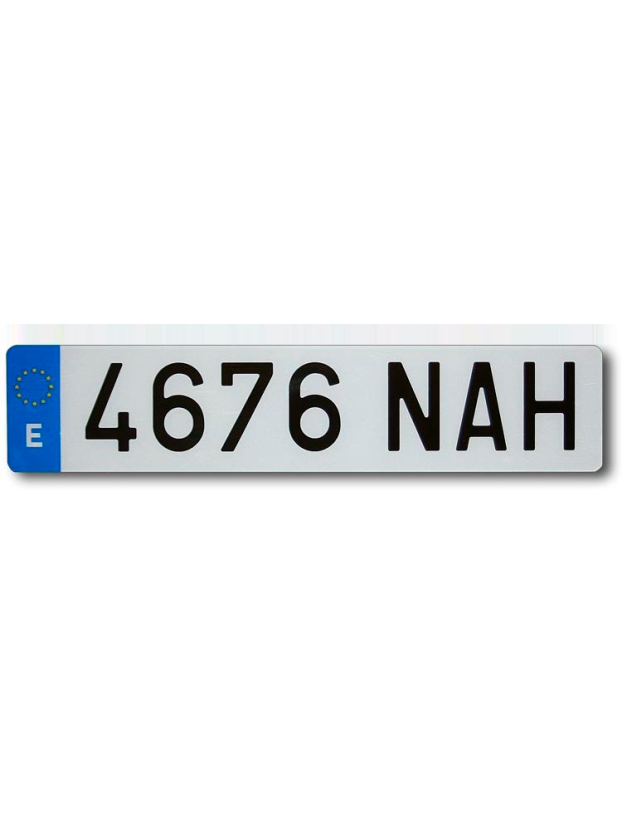

In [17]:
ejemplo = project_dir / "data" / "IAM" / "image" / "internet" / "placa-matricula-acrilica-normal-para-coche.jpg"
if ejemplo.is_file():
    print(transcribir(ejemplo))
    display(Image.open(ejemplo))

## Exportar a TFLite

Convertimos el modelo guardado en `OUTPUT_DIR / "final"` a TFLite (LiteRT) con `scripts/exportar_ocr_tflite.py`. TrOCR
genera el texto token a token, así que el `.tflite` tiene dos firmas:

* `encoder`: `pixel_values` float32 `[1, 3, alto, ancho]` (redimensionado y normalizado como hace el procesador) →
  características de la imagen.
* `decoder`: `input_ids` int32 `[1, 16]` y las características → `logits` `[1, 16, vocabulario]`.

La lectura se hace fuera del modelo: se empieza con `[inicio, pad, pad, …]` y en cada paso `t` el siguiente token es el
máximo de `logits[0, t]`, hasta el token de fin (búsqueda voraz, sin caché gracias a la longitud fija). Se guardan en
`OUTPUT_DIR / "tflite"`:

* `trocr_placas.tflite` (float32, ~1,5 GB) y `trocr_placas_int8.tflite` (pesos int8, ~400 MB, para móviles);
* `vocabulario.json` (id de token → texto) y `config_tflite.json` (tamaño, normalización y tokens especiales).

`litert-torch` no es compatible con el entorno de TrOCR, así que el script se ejecuta con el Python del entorno `detr`
del contenedor, que ya lo incluye. Antes se guardan como PNG algunas placas de test de cada fuente, con el mismo recorte
que en la evaluación, y el script compara sus lecturas en PyTorch (beam search y voraz) y en los dos `.tflite`.

In [10]:
import csv
import subprocess

PYTHON_DETR = Path("/opt/conda/envs/detr/bin/python")
if not PYTHON_DETR.exists():
    raise FileNotFoundError("La exportación usa el entorno detr del contenedor Docker (no existe " + str(PYTHON_DETR) + ")")

TFLITE_DIR = OUTPUT_DIR / "tflite"
muestras_dir = TFLITE_DIR / "muestras"
muestras_dir.mkdir(parents=True, exist_ok=True)
n_por_fuente = min(25, int(test_df["fuente"].value_counts().min()))
muestras_csv = TFLITE_DIR / "muestras.csv"
with open(muestras_csv, "w", newline="", encoding="utf-8") as f:
    escritor = csv.writer(f)
    escritor.writerow(["path", "text"])
    for idx in test_df.groupby("fuente").sample(n_por_fuente, random_state=SEED).index:
        ruta = muestras_dir / f"{test_df['fuente'][idx]}_{idx}.png"
        test_dataset.load_image(idx).save(ruta)  # mismo recorte que en la evaluación
        escritor.writerow([str(ruta), test_df["text"][idx]])

proceso = subprocess.run(
    [str(PYTHON_DETR), str(project_dir / "scripts" / "exportar_ocr_tflite.py"), str(OUTPUT_DIR / "final"),
     "--salida", str(TFLITE_DIR), "--muestras", str(muestras_csv)],
    capture_output=True, text=True,
)
salida = proceso.stdout + proceso.stderr
if "No module named 'litert_torch'" in salida:
    raise RuntimeError("Falta litert-torch en el entorno detr: reconstruye la imagen o ejecuta\n"
                       'docker compose exec trocr micromamba run -n detr pip install "litert-torch==0.9.0" '
                       '"torchao==0.12.0" "pydantic==2.11.10"')
claves = ("Modelo ", "Convertido", "Pesos int8", "Vocabulario", "Placas leídas", "  PyTorch", "  TFLite", "Error", "error")
print("\n".join(linea for linea in salida.splitlines() if linea.startswith(claves)))
if proceso.returncode != 0:
    print(salida[-3000:])
    raise RuntimeError(f"La exportación falló (código {proceso.returncode})")

Modelo /home/mambauser/workspace/outputs/trocr_placas_rellenas_colombia/final: entrada 128x128, max_length 16
Convertido en 38s: /home/mambauser/workspace/outputs/trocr_placas_rellenas_colombia/tflite/trocr_placas.tflite (1541 MB)
Pesos int8: /home/mambauser/workspace/outputs/trocr_placas_rellenas_colombia/tflite/trocr_placas_int8.tflite (394 MB)
Vocabulario y configuración en /home/mambauser/workspace/outputs/trocr_placas_rellenas_colombia/tflite
Placas leídas sin errores (50 muestras):
  PyTorch beam search     62.0%
  PyTorch voraz           62.0%
  TFLite float32          62.0%
  TFLite int8             62.0%
  TFLite float32: misma lectura que PyTorch voraz en 50/50; 577 ms por placa en CPU
  TFLite int8: misma lectura que PyTorch voraz en 50/50; 658 ms por placa en CPU
